In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
dataset = pd.read_csv('Mall_Customers.csv')
print(dataset.head())
X = dataset.iloc[:, [3, 4]].values
print(X)


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [

Optimal eps: 10.0


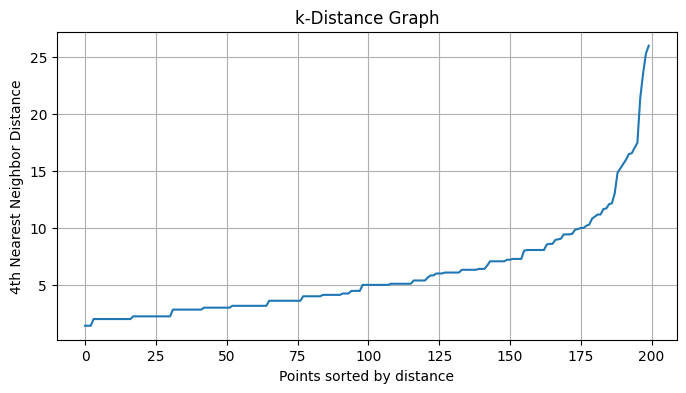

In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = X.shape[1] * 2

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort the k-distances (min_samples-th nearest distance)
k_distances = np.sort(distances[:, -1])


from kneed import KneeLocator

kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
eps = k_distances[kneedle.knee]
print("Optimal eps:", eps)


plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}th Nearest Neighbor Distance")
plt.grid(True)
plt.show()



In [5]:
from sklearn.cluster import DBSCAN

dbscan_clust = DBSCAN(eps=10, min_samples=4)
y_dbscan_clust = dbscan_clust.fit_predict(X)

unique, counts = np.unique(y_dbscan_clust, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(-1): np.int64(15), np.int64(0): np.int64(125), np.int64(1): np.int64(33), np.int64(2): np.int64(27)}


In [6]:
supervised=pd.DataFrame(dataset)

supervised['Cluster_group']=y_dbscan_clust

supervised


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


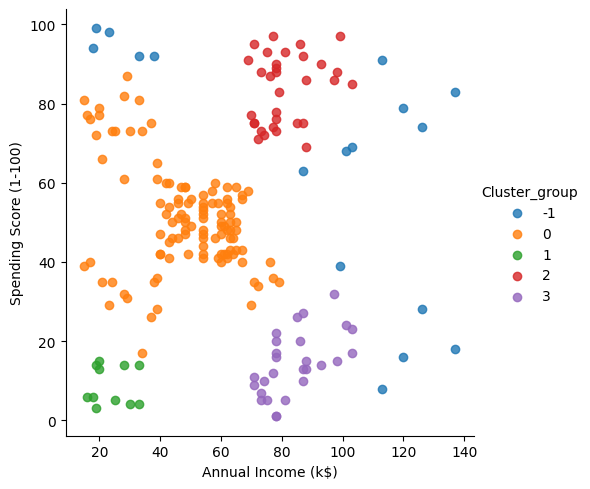

In [37]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True)
